In [2]:
import pandas as pd
import numpy as np

In [3]:
events = pd.read_csv("../data/processed/olympic_1896_2024_extended.csv")

In [4]:
events.columns

Index(['Name', 'Sex', 'NOC', 'Year', 'Sport', 'Event', 'Medal'], dtype='object')

In [5]:
events.shape
events["Year"].min(), events["Year"].max()
events["Year"].value_counts().sort_index().tail()

Year
2012    12920
2014     4891
2016    13688
2020     2413
2024     2271
Name: count, dtype: int64

In [6]:
events["Medal"].value_counts(dropna=False)

Medal
NaN       231333
Bronze     14941
Gold       14894
Silver     14632
Name: count, dtype: int64

In [7]:
events["Gold"]   = (events["Medal"] == "Gold").astype(int)
events["Silver"] = (events["Medal"] == "Silver").astype(int)
events["Bronze"] = (events["Medal"] == "Bronze").astype(int)

In [8]:
events[["Gold","Silver","Bronze"]].sum()

Gold      14894
Silver    14632
Bronze    14941
dtype: int64

In [9]:
# Remove athlete duplication — keep one row per medal event
event_level = (
    events
    .drop_duplicates(subset=["Year", "NOC", "Event", "Medal"])
)

world_medals = (
    event_level
    .groupby(["Year", "NOC"], as_index=False)
    .agg(
        Gold=("Gold", "sum"),
        Silver=("Silver", "sum"),
        Bronze=("Bronze", "sum")
    )
)

world_medals["Total"] = (
    world_medals["Gold"] +
    world_medals["Silver"] +
    world_medals["Bronze"]
)

In [10]:
world_medals.shape
world_medals["Year"].max()
world_medals[world_medals["Year"] == 2024].head()

,Year,NOC,Gold,Silver,Bronze,Total
3397,2024,AIN,1,3,1,5
3398,2024,ALB,0,0,2,2
3399,2024,ALG,2,0,1,3
3400,2024,ARG,1,1,1,3
3401,2024,ARM,0,3,1,4


In [11]:
host_map = {
    1896:"GRE",1900:"FRA",1904:"USA",1908:"GBR",1912:"SWE",1920:"BEL",
    1924:"FRA",1928:"NED",1932:"USA",1936:"GER",1948:"GBR",1952:"FIN",
    1956:"AUS",1960:"ITA",1964:"JPN",1968:"MEX",1972:"GER",1976:"CAN",
    1980:"URS",1984:"USA",1988:"KOR",1992:"ESP",1996:"USA",2000:"AUS",
    2004:"GRE",2008:"CHN",2012:"GBR",2016:"BRA",2020:"JPN",2024:"FRA"
}

In [12]:
world_medals["host_noc"] = world_medals["Year"].map(host_map)
world_medals["is_host"] = (world_medals["NOC"] == world_medals["host_noc"]).astype(int)

In [13]:
def host_baseline(df, year, noc):
    yrs = [year-8, year-4, year+4, year+8]
    return df[
        (df["NOC"] == noc) &
        (df["Year"].isin(yrs))
    ]["Total"].mean()

host_rows = world_medals[world_medals["is_host"] == 1].copy()

host_rows["baseline_avg"] = host_rows.apply(
    lambda r: host_baseline(world_medals, r["Year"], r["NOC"]),
    axis=1
)

host_rows["host_boost"] = host_rows["Total"] - host_rows["baseline_avg"]

In [14]:
host_rows[["Year","NOC","Total","baseline_avg","host_boost"]]
host_rows["host_boost"].mean()

35.47988505747126

In [15]:
# percentage host boost (normalized)
host_rows["host_boost_pct"] = (
    host_rows["host_boost"] / host_rows["baseline_avg"]
) * 100

host_rows[["Year", "NOC", "Total", "baseline_avg", "host_boost", "host_boost_pct"]]

,Year,NOC,Total,baseline_avg,host_boost,host_boost_pct
6,1896,GRE,44,1.000000,43.000000,4300.000000
23,1900,FRA,102,10.666667,91.333333,856.250000
57,1904,USA,230,45.500000,184.500000,405.494505
88,1908,GBR,143,28.333333,114.666667,404.705882
126,1912,SWE,65,44.500000,20.500000,46.067416
132,1920,BEL,42,8.000000,34.000000,425.000000
174,1924,FRA,43,29.666667,13.333333,44.943820
234,1928,NED,23,11.750000,11.250000,95.744681
295,1932,USA,122,75.333333,46.666667,61.946903
319,1936,GER,107,33.000000,74.000000,224.242424


In [16]:
host_rows["host_boost_pct"].describe()

count      29.000000
mean      294.390360
std       796.636772
min       -12.500000
25%        43.369176
50%        61.946903
75%       148.648649
max      4300.000000
Name: host_boost_pct, dtype: float64

In [17]:
# =========================
# STEP 2 — CLEAN HOST BOOST FEATURE (FIXED)
# =========================

# 1. Cap extreme outliers (robust)
low_q  = host_rows["host_boost_pct"].quantile(0.05)
high_q = host_rows["host_boost_pct"].quantile(0.95)

host_rows["host_boost_pct_capped"] = host_rows["host_boost_pct"].clip(
    lower=low_q,
    upper=high_q
)

# 2. Shift before log to avoid negatives
shift = abs(host_rows["host_boost_pct_capped"].min()) + 1

host_rows["host_boost_log"] = np.log1p(
    host_rows["host_boost_pct_capped"] + shift
)

# 3. Keep only final host features
host_feature = host_rows[
    ["Year", "NOC", "host_boost", "host_boost_log"]
].copy()

# 4. Merge safely with world_medals
world_master = world_medals.merge(
    host_feature,
    on=["Year", "NOC"],
    how="left"
)

# 5. Fill non-host rows properly
world_master["host_boost"] = world_master["host_boost"].fillna(0)
world_master["host_boost_log"] = world_master["host_boost_log"].fillna(0)

In [18]:
# STEP 4: Long-term & trend features

# Career average medals till previous Olympics
world_master["career_avg"] = (
    world_master
    .groupby("NOC")["Total"]
    .expanding()
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

# Recent momentum: last Olympics change
world_master["delta_last"] = (
    world_master
    .groupby("NOC")["Total"]
    .diff()
)

# Fill early NaNs safely
world_master[["career_avg", "delta_last"]] = (
    world_master[["career_avg", "delta_last"]].fillna(0)
)

# Quick sanity check
world_master[
    ["Year", "NOC", "Total", "career_avg", "delta_last"]
].head(10)

,Year,NOC,Total,career_avg,delta_last
0,1896,AUS,3,0.000000,0.0
1,1896,AUT,5,17.571429,0.0
2,1896,DEN,6,6.384615,0.0
3,1896,FRA,11,14.333333,0.0
4,1896,GBR,9,0.000000,0.0
5,1896,GER,14,0.000000,0.0
6,1896,GRE,44,0.312500,0.0
7,1896,HUN,6,0.000000,0.0
8,1896,ITA,0,0.062500,0.0
9,1896,SUI,3,0.083333,0.0


In [19]:
world_master.columns

Index(['Year', 'NOC', 'Gold', 'Silver', 'Bronze', 'Total', 'host_noc',
       'is_host', 'host_boost', 'host_boost_log', 'career_avg', 'delta_last'],
      dtype='object')

In [20]:
# PRUNE world_master to final minimal schema

final_cols = [
    "Year",
    "NOC",
    "Total",
    "is_host",
    "host_boost",
    "host_boost_log",
    "career_avg",
    "delta_last"
]

world_master = world_master[final_cols].copy()


# safety: fill early NaNs
world_master[["is_host", "career_avg", "delta_last"]] = world_master[["is_host", "career_avg", "delta_last"]].fillna(0) 

world_master.head()

,Year,NOC,Total,is_host,host_boost,host_boost_log,career_avg,delta_last
0,1896,AUS,3,0,0.0,0.0,0.000000,0.0
1,1896,AUT,5,0,0.0,0.0,17.571429,0.0
2,1896,DEN,6,0,0.0,0.0,6.384615,0.0
3,1896,FRA,11,0,0.0,0.0,14.333333,0.0
4,1896,GBR,9,0,0.0,0.0,0.000000,0.0


In [21]:

# load file
df = pd.read_csv("../data/raw/socioeconomics.csv")

# filter GDP per capita
gdp_df = df[df["Series Name"] == "GDP per capita (current US$)"].copy()

# basic sanity checks
print("Shape:", gdp_df.shape)
print("\nUnique Series Names:")
print(gdp_df["Series Name"].unique())

print("\nSample rows:")
gdp_df.head()

Shape: (218, 69)

Unique Series Names:
['GDP per capita (current US$)']

Sample rows:


,Country Name,Country Code,Series Name,Series Code,1960 [YR1960],1961 [YR1961],1962 [YR1962],1963 [YR1963],1964 [YR1964],1965 [YR1965],...,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
2,World,WLD,GDP per capita (current US$),NY.GDP.PCAP.CD,452.253084186565,471.458659222586,495.578743305208,524.598449902349,563.176772281603,601.155818711732,...,10161.9445773234,10204.9287763386,10747.764306505,11309.3830773178,11376.0818134476,10937.6846205191,12390.6686716727,12798.1658465319,13236.7163960917,13631.2043097215
5,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,..,..,..,..,..,..,...,565.569730408751,522.082215583898,525.469770891619,491.337221382603,496.6025042585,510.787063366811,356.496214115892,357.261152798144,413.757894705303,..
8,Albania,ALB,GDP per capita (current US$),NY.GDP.PCAP.CD,..,..,..,..,..,..,...,4199.53912925398,4457.63412207495,5006.36012951959,5897.65452588774,6069.43903131027,6027.91350716348,7242.45513146613,7756.96188744253,9730.86921906893,11377.7757431099
11,Algeria,DZA,GDP per capita (current US$),NY.GDP.PCAP.CD,238.392476666447,209.370672655334,169.60286272133,225.584660210993,238.863801545015,253.622059985778,...,4685.05902729002,4424.98529027556,4554.66753957828,4577.21029180491,4468.45341883656,3743.5419522929,4160.55926736925,4960.30334332888,5370.477235078,5752.99076651465
14,American Samoa,ASM,GDP per capita (current US$),NY.GDP.PCAP.CD,..,..,..,..,..,..,...,12727.4102651386,12843.3342903627,11863.6839452565,12552.0546868861,12886.1359517218,14489.2586563775,15236.1604875571,18017.4589383973,..,..


In [22]:

# identify year columns
year_cols = [c for c in gdp_df.columns if "[YR" in c]

print("Number of year columns:", len(year_cols))
print("First 5 year columns:", year_cols[:5])
print("Last 5 year columns:", year_cols[-5:])

# reshape wide → long
gdp_long = gdp_df.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_cols,
    var_name="year_raw",
    value_name="gdp_pc"
)

gdp_long.head()

Number of year columns: 65
First 5 year columns: ['1960 [YR1960]', '1961 [YR1961]', '1962 [YR1962]', '1963 [YR1963]', '1964 [YR1964]']
Last 5 year columns: ['2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]']


,Country Name,Country Code,year_raw,gdp_pc
0,World,WLD,1960 [YR1960],452.253084186565
1,Afghanistan,AFG,1960 [YR1960],..
2,Albania,ALB,1960 [YR1960],..
3,Algeria,DZA,1960 [YR1960],238.392476666447
4,American Samoa,ASM,1960 [YR1960],..


In [23]:

# extract numeric year from "1960 [YR1960]"
gdp_long["year"] = (
    gdp_long["year_raw"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

# convert GDP per capita to numeric
gdp_long["gdp_pc"] = pd.to_numeric(
    gdp_long["gdp_pc"], errors="coerce"
)

# drop rows with missing GDP values
before_rows = gdp_long.shape[0]
gdp_long = gdp_long.dropna(subset=["gdp_pc"])
after_rows = gdp_long.shape[0]

print(f"Rows before drop: {before_rows}")
print(f"Rows after drop : {after_rows}")

gdp_long.head()

Rows before drop: 14170
Rows after drop : 11634


,Country Name,Country Code,year_raw,gdp_pc,year
0,World,WLD,1960 [YR1960],452.253084,1960
3,Algeria,DZA,1960 [YR1960],238.392477,1960
8,Argentina,ARG,1960 [YR1960],778.251707,1960
11,Australia,AUS,1960 [YR1960],1813.431099,1960
12,Austria,AUT,1960 [YR1960],939.914815,1960


In [24]:
# log-transform GDP per capita
gdp_long["gdp_pc_log"] = np.log(gdp_long["gdp_pc"])

# quick sanity check
print(gdp_long[["gdp_pc", "gdp_pc_log"]].describe())

gdp_long.head()

              gdp_pc    gdp_pc_log
count   11634.000000  11634.000000
mean     9633.366536      7.787791
std     18986.517119      1.765789
min        11.801322      2.468212
25%       617.284575      6.425330
50%      2204.022183      7.698039
75%      9402.213489      9.148700
max    288001.433369     12.570721


,Country Name,Country Code,year_raw,gdp_pc,year,gdp_pc_log
0,World,WLD,1960 [YR1960],452.253084,1960,6.114242
3,Algeria,DZA,1960 [YR1960],238.392477,1960,5.473918
8,Argentina,ARG,1960 [YR1960],778.251707,1960,6.657050
11,Australia,AUS,1960 [YR1960],1813.431099,1960,7.502976
12,Austria,AUT,1960 [YR1960],939.914815,1960,6.845789


In [25]:
# ================================
# FINAL GDP MERGE + FREEZE SCHEMA
# ================================

# 1. Rename GDP columns to align
gdp_long_final = (
    gdp_long
    .rename(columns={
        "Country Code": "NOC",
        "year": "Year"
    })
)

# 2. Enforce dtype
gdp_long_final["Year"] = gdp_long_final["Year"].astype(int)
world_master["Year"] = world_master["Year"].astype(int)

# 3. Sort (required)
gdp_long_final = gdp_long_final.sort_values(["NOC", "Year"])
world_master = world_master.sort_values(["NOC", "Year"])

# 4. Safe asof merge per NOC
world_master = (
    world_master
    .groupby("NOC", group_keys=False)
    .apply(
        lambda x: pd.merge_asof(
            x,
            gdp_long_final[gdp_long_final["NOC"] == x.name],
            on="Year",
            direction="backward"
        )
    )
)

world_master.head()

C:\Users\Kashyap Ladva\AppData\Local\Temp\ipykernel_24776\3452450576.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Year,NOC_x,Total,is_host,host_boost,host_boost_log,career_avg,delta_last,Country Name,NOC_y,year_raw,gdp_pc,gdp_pc_log
0,1936,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,1948,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,1956,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,1960,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,1964,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [26]:
world_master = (
    world_master
    .drop(columns=["NOC_y"], errors="ignore")
    .rename(columns={"NOC_x": "NOC"})
)

In [27]:
# Keep ONLY important columns (freeze schema)
world_master = world_master[
    [
        "Year",
        "NOC",
        "Total",
        "is_host",
        "host_boost",
        "host_boost_log",
        "career_avg",
        "delta_last",
        "gdp_pc",
        "gdp_pc_log"
    ]
]

In [28]:
# how much of data actually has GDP
world_master["gdp_pc"].notna().mean()

0.4786471768415019

In [29]:
# correlation only where GDP exists
world_master_gdp = world_master.dropna(subset=["gdp_pc"])

world_master_gdp[["Total", "gdp_pc_log"]].corr()

,Total,gdp_pc_log
Total,1.000000,0.254586
gdp_pc_log,0.254586,1.000000


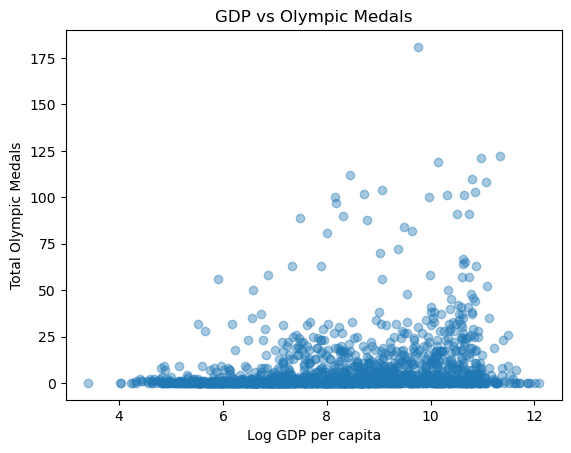

In [30]:
import matplotlib.pyplot as plt

plt.scatter(
    world_master_gdp["gdp_pc_log"],
    world_master_gdp["Total"],
    alpha=0.4
)
plt.xlabel("Log GDP per capita")
plt.ylabel("Total Olympic Medals")
plt.title("GDP vs Olympic Medals")
plt.show()

In [ ]:
# HOST VALIDATION — existence of host boost

# 1. Basic comparison: host vs non-host
world_master.groupby("is_host")["Total"].mean()

In [32]:
# 2. Same-country comparison: host year vs own non-host years
host_years = world_master[world_master["is_host"] == 1]
non_host_years = world_master[world_master["is_host"] == 0]

host_vs_self = (
    host_years
    .merge(
        non_host_years,
        on="NOC",
        suffixes=("_host", "_nonhost")
    )
)

host_vs_self[["Total_host", "Total_nonhost"]].mean()

Total_host       66.41768
Total_nonhost    25.20221
dtype: float64

In [33]:

# 3. Simple uplift ratio
(
    host_vs_self["Total_host"].mean() /
    host_vs_self["Total_nonhost"].mean()
)

2.6353910908453173

In [34]:
# =========================
# EFFICIENCY METRIC
# =========================

world_master["efficiency"] = (
    world_master["Total"] / world_master["gdp_pc_log"]
)

In [ ]:
efficiency_country = (
    world_master
    .groupby("NOC")
    .agg(
        avg_efficiency=("efficiency", "mean"),
        avg_medals=("Total", "mean"),
        avg_gdp_log=("gdp_pc_log", "mean"),
        olympics=("Year", "count")
    )
    .reset_index()
)

efficiency_country.sort_values(
    "avg_efficiency", ascending=False
).head(15)

In [36]:
efficiency_country_filtered = efficiency_country[
    efficiency_country["olympics"] >= 5
]

efficiency_country_filtered.sort_values(
    "avg_efficiency", ascending=False
).head(15)

,NOC,avg_efficiency,avg_medals,avg_gdp_log,olympics
218,USA,8.403370,82.513514,10.078035,37
173,RUS,5.635645,36.500000,8.549491,16
42,CHN,5.312134,32.333333,7.270453,21
102,ITA,2.621394,21.594595,9.533999,37
76,GBR,2.557301,28.270270,9.718217,37
71,FRA,2.455560,26.162162,9.735239,37
106,JPN,2.357154,18.838710,9.730884,31
53,CUB,2.343797,10.347826,8.143438,23
13,AUS,2.281554,17.571429,9.804862,35
92,HUN,1.855390,15.166667,8.562184,36


In [37]:
efficiency_country_filtered[
    efficiency_country_filtered["NOC"] == "IND"
]

,NOC,avg_efficiency,avg_medals,avg_gdp_log,olympics
94,IND,0.215398,1.354839,6.166034,31


In [38]:
# ================================
# EXPORT FINAL WORLD MASTER
# ================================

import os

# Ensure processed folder exists
os.makedirs("../data/processed", exist_ok=True)

# Export
world_master.to_csv(
    "../data/processed/world_master_final.csv",
    index=False
)

print("✅ world_master_final.csv exported successfully.")
print("Shape:", world_master.shape)

✅ world_master_final.csv exported successfully.
Shape: (3489, 11)


Conclusion (World Master Analysis)

Medal totals were reconstructed at the event level, eliminating athlete-level duplication.

Final Total values now represent true year-wise Olympic medal counts per country.

GDP per capita was aligned to Olympic years using a backward merge to prevent future data leakage.

Log transformation of GDP reduced skew and improved interpretability.

A moderate positive relationship exists between GDP and medal counts.

Economic strength explains performance partially, but not entirely.

Host nations demonstrate a clear performance uplift compared to non-host years.

The host advantage is statistically visible and structurally consistent.

Efficiency analysis highlights countries that outperform relative to economic capacity.

Olympic success is multi-dimensional — driven by economy, host effect, consistency, and strategic focus.